Prueba con el G1

In [1]:
import mujoco
import mediapy as media
from scipy.spatial.transform import Rotation as R

Añado el robot utilizando la ruta al xml

""

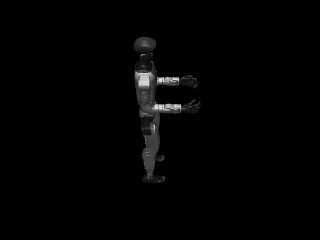

In [2]:
model = mujoco.MjModel.from_xml_path("../../../../mjlab/src/mjlab/asset_zoo/robots/unitree_g1/xmls/g1.xml")
data = mujoco.MjData(model)

with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

In [3]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


Cuando lo simulo no tiene suelo por lo que se cae

Muevo el modelo a la carpeta para poder importarlo y añadir suelo

""

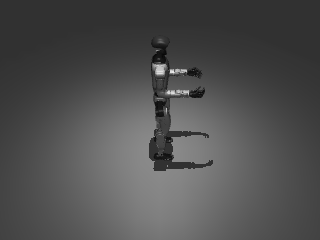

In [4]:
xml = """
<mujoco>
  <include file="g1.xml"/>
  <worldbody>
  
    <geom name="plane" type="plane" size="5 5 0.1"/>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

In [5]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


In [6]:
for i in range(model.nu):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, i)
    print(i, name)

El modelo no tiene las articulaciones configuradas por lo que no detecta ninguna

Importo el modelo desde g1_constants.py para que tenga articulaciones

""

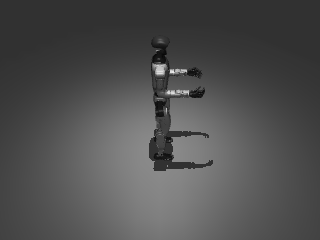

In [7]:
import mujoco
from mjlab.entity.entity import Entity
from g1_constants import get_g1_robot_cfg

robot = Entity(get_g1_robot_cfg())

spec = robot.spec

world = spec.worldbody
world.add_geom(
    name="floor",
    type=mujoco.mjtGeom.mjGEOM_PLANE,
    size=[5, 5, 0.1],
    pos=[0, 0, 0],
)

model = spec.compile()
data = mujoco.MjData(model)

with mujoco.Renderer(model) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data)

    media.show_image(renderer.render())

In [8]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


In [9]:
for i in range(model.nu):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, i)
    print(i, name)

0 left_shoulder_pitch_joint
1 left_shoulder_roll_joint
2 left_shoulder_yaw_joint
3 left_elbow_joint
4 left_wrist_roll_joint
5 right_shoulder_pitch_joint
6 right_shoulder_roll_joint
7 right_shoulder_yaw_joint
8 right_elbow_joint
9 right_wrist_roll_joint
10 left_hip_pitch_joint
11 left_hip_yaw_joint
12 right_hip_pitch_joint
13 right_hip_yaw_joint
14 waist_yaw_joint
15 left_hip_roll_joint
16 left_knee_joint
17 right_hip_roll_joint
18 right_knee_joint
19 left_wrist_pitch_joint
20 left_wrist_yaw_joint
21 right_wrist_pitch_joint
22 right_wrist_yaw_joint
23 waist_roll_joint
24 waist_pitch_joint
25 left_ankle_pitch_joint
26 left_ankle_roll_joint
27 right_ankle_pitch_joint
28 right_ankle_roll_joint


In [10]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    data.ctrl[14] = 1
    data.ctrl[5] = 2
    data.ctrl[3] = -1
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


Incluyo la red neuronal para probar su funcionamiento

In [11]:
import numpy as np
import onnxruntime as ort
import wandb

In [12]:
api = wandb.Api()
run = api.run("lopezmuniciodiego-universidad-rey-juan-carlos/mjlab/uc8atgr3")

file = run.file("2026-01-26_10-42-02.onnx")
file.download(exist_ok=True)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/d/.netrc.


<_io.TextIOWrapper name='./2026-01-26_10-42-02.onnx' mode='r' encoding='UTF-8'>

In [13]:
session = ort.InferenceSession("2026-01-26_10-42-02.onnx")

Miro sus entradas y salidas

In [14]:
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

print("Input:", input_name)
print("Output:", output_name)

Input: obs
Output: actions


Miro de que tipo son las entradas y salidas

In [15]:
for i in session.get_inputs():
    print(i.name, i.shape, i.type)

for o in session.get_outputs():
    print(o.name, o.shape, o.type)

obs [1, 99] tensor(float)
actions [1, 29] tensor(float)


Compruebo como devuelve los datos de los sensores mujoco

In [16]:
for i in range(model.nsensor):
    # Nombre del sensor
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_SENSOR, i)
    
    # Tipo del sensor
    sensor_type = model.sensor_type[i]  # devuelve un entero
    type_name = mujoco.mjtSensor(sensor_type).name  # convierte a nombre legible
    
    # Dirección y dimensión en el array sensordata
    start = model.sensor_adr[i]
    dim = model.sensor_dim[i]
    
    # Valores del sensor
    values = data.sensordata[start : start + dim]
    
    # Imprimir
    print(f"Sensor '{name}' (tipo {type_name}): {values}")

Sensor 'imu_ang_vel' (tipo mjSENS_GYRO): [-0.00183039  0.00030883 -0.00131259]
Sensor 'imu_lin_vel' (tipo mjSENS_VELOCIMETER): [-5.17319334e-05  3.64246181e-04  2.63510049e-05]
Sensor 'imu_lin_acc' (tipo mjSENS_ACCELEROMETER): [-9.80727422 -0.1814618  -0.13946085]
Sensor 'root_angmom' (tipo mjSENS_SUBTREEANGMOM): [ 4.84087841e-05 -1.36371445e-04 -3.34907808e-03]


Obtengo los valores de la gravedad

In [17]:
g = model.opt.gravity
print("Gravedad global:", g)

Gravedad global: [ 0.    0.   -9.81]


Obtengo las posiciones de las articulaciones

In [18]:
qpos = data.qpos
print("Posiciones de todas las articulaciones:", qpos)
print(len(qpos))

Posiciones de todas las articulaciones: [ 9.60618964e-01 -6.66282337e-02  9.40692347e-02  7.01277361e-01
  2.05183574e-02  7.11818976e-01 -3.32085263e-02  5.62535442e-02
 -3.46224688e-03 -4.90994102e-04 -1.06625250e-03  1.44955545e-02
 -4.21617255e-04  3.34209798e-02  5.20181271e-03 -4.02463880e-03
  2.84930999e-02  3.19461634e-02  3.52153856e-04  9.18932392e-01
 -2.41251538e-02  6.00829383e-03 -1.54589687e-01 -1.32083574e-01
 -7.60060392e-02 -9.13894099e-01 -1.01873532e-04  1.59751207e-02
 -7.21790756e-03  1.90440581e+00 -6.97808011e-02 -9.36409045e-02
 -1.05579575e-01  4.44083377e-04 -1.88226384e-02 -6.27439090e-03]
36


También las velocidades

In [19]:
qvel = data.qvel
print("Velocidades de todas las articulaciones:", qvel)
print(len(qvel))

Velocidades de todas las articulaciones: [ 8.41643939e-05  5.71420364e-04  1.47042170e-05 -1.82684405e-03
  3.08015970e-04 -1.30887284e-03  2.14745431e-04  1.82373535e-03
 -1.25797056e-03 -8.91580220e-04  1.04155210e-03  3.76965903e-04
 -1.43734580e-03  6.17849427e-04 -1.43001252e-03  1.02017256e-03
  3.55116317e-03  1.95833699e-04  1.37906290e-03  3.52460386e-03
 -4.99515466e-03  1.30697927e-05  1.35966612e-06 -1.18828344e-05
 -1.23672798e-06 -8.02138357e-08 -1.25235038e-07 -1.14357974e-06
 -2.75833004e-03  4.36204248e-04  1.28191312e-03 -5.53057073e-06
 -2.05342837e-07  2.40870663e-06  1.36332807e-06]
35


Creo el twist que recibirá el robot

In [20]:
twist = [1, 0, 0]

In [21]:
sensor_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SENSOR, "imu_lin_vel")
start = model.sensor_adr[sensor_id]
dim = model.sensor_dim[sensor_id]

obs = data.sensordata[start : start + dim]

sensor_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SENSOR, "imu_ang_vel")
start = model.sensor_adr[sensor_id]
dim = model.sensor_dim[sensor_id]

obs = np.append(obs, data.sensordata[start : start + dim])

quat = data.xquat[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "robot")]
quat = np.array([quat[1], quat[2], quat[3], quat[0]])
rot = R.from_quat(quat)
g_world = np.array([0,0,-1])
projected_gravity = rot.inv().apply(g_world)

obs = np.append(obs, projected_gravity)

obs = np.append(obs, data.qpos[7:])
obs = np.append(obs, data.qvel[6:])

last_action = np.zeros(29)

obs = np.append(obs, last_action)

obs = np.append(obs, twist)
print(obs.shape)
print(obs)

(99,)
[-5.17319334e-05  3.64246181e-04  2.63510049e-05 -1.83038876e-03
  3.08829282e-04 -1.31259018e-03  1.60282247e-01 -5.95734976e-01
  7.87025692e-01  5.62535442e-02 -3.46224688e-03 -4.90994102e-04
 -1.06625250e-03  1.44955545e-02 -4.21617255e-04  3.34209798e-02
  5.20181271e-03 -4.02463880e-03  2.84930999e-02  3.19461634e-02
  3.52153856e-04  9.18932392e-01 -2.41251538e-02  6.00829383e-03
 -1.54589687e-01 -1.32083574e-01 -7.60060392e-02 -9.13894099e-01
 -1.01873532e-04  1.59751207e-02 -7.21790756e-03  1.90440581e+00
 -6.97808011e-02 -9.36409045e-02 -1.05579575e-01  4.44083377e-04
 -1.88226384e-02 -6.27439090e-03  2.14745431e-04  1.82373535e-03
 -1.25797056e-03 -8.91580220e-04  1.04155210e-03  3.76965903e-04
 -1.43734580e-03  6.17849427e-04 -1.43001252e-03  1.02017256e-03
  3.55116317e-03  1.95833699e-04  1.37906290e-03  3.52460386e-03
 -4.99515466e-03  1.30697927e-05  1.35966612e-06 -1.18828344e-05
 -1.23672798e-06 -8.02138357e-08 -1.25235038e-07 -1.14357974e-06
 -2.75833004e-03  4

In [22]:
obs = obs.reshape(1, -1)
print(obs.shape)

(1, 99)


In [23]:
result = session.run([output_name], {input_name: obs.astype(np.float32)})[0]
print(result)
print(result.shape)

[[-0.5877949  -0.09289451  0.37118495  0.5709882   0.28856885  0.2718996
   1.0935454   0.10693379  0.52147615 -0.69877553 -0.6667454   1.0388031
  -0.08379483 -1.9542949  -0.5466778   0.5455967   0.27300104  0.43399745
   0.3193813  -0.34964237 -0.2293599   0.55242866 -1.7889009  -0.5360787
  -0.19279823 -0.44646117  0.08641937  0.73214424  1.353189  ]]
(1, 29)


In [24]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

twist = [1, 0, 0]
last_action = np.zeros(29)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.

with mujoco.Renderer(model) as renderer:
  while data.time < 0.1:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

with mujoco.Renderer(model) as renderer:
  while data.time < duration:

    sensor_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SENSOR, "imu_lin_vel")
    start = model.sensor_adr[sensor_id]
    dim = model.sensor_dim[sensor_id]

    obs = data.sensordata[start : start + dim]

    sensor_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SENSOR, "imu_ang_vel")
    start = model.sensor_adr[sensor_id]
    dim = model.sensor_dim[sensor_id]

    obs = np.append(obs, data.sensordata[start : start + dim])

    quat = data.xquat[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "robot")]
    quat = np.array([quat[1], quat[2], quat[3], quat[0]])
    rot = R.from_quat(quat)
    g_world = np.array([0,0,-1])
    projected_gravity = rot.inv().apply(g_world)

    obs = np.append(obs, projected_gravity)

    obs = np.append(obs, data.qpos[7:])
    obs = np.append(obs, data.qvel[6:])

    last_action = np.zeros(29)

    obs = np.append(obs, last_action)

    obs = np.append(obs, twist)

    obs = obs.reshape(1, -1)

    result = session.run([output_name], {input_name: obs.astype(np.float32)})[0][0]

    for i in range(len(result)):
      data.ctrl[i] = result[i]

    last_action = result
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.
